In [ ]:
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))

if parent_dir not in os.sys.path:
    os.sys.path.append(parent_dir)

from extractors.feature_extraction import UpliftFeatureExtractor
from sklift.datasets import fetch_x5
from sklift.metrics import uplift_auc_score, qini_auc_score, uplift_at_k

from causalml.inference.tree import UpliftRandomForestClassifier

In [2]:
dataset = fetch_x5()
data = dataset.data

# генерация фич
extractor = UpliftFeatureExtractor(drop_redundant=True)
df = extractor.calculate_features(
    clients_df=data.clients,
    train_df=data.train,
    treatment_df=dataset.treatment,
    target_df=dataset.target,
    purchases_df=data.purchases
)

features = extractor.feature_names
print(f"Создано признаков: {len(features)}")
print(f"Размер датафрейма: {df.shape}")

# очистка памяти
del data
gc.collect()

Создано признаков: 32
Размер датафрейма: (200039, 34)


66

In [3]:
X_all = df[features].copy()
y = df['target'].values

# "0" - контроль, "1" - тритмент
t_str = np.where(df['treatment_flg'] == 1, 'treatment', 'control')

# стратификация
strata = df[['treatment_flg', 'target']].astype(str).agg("_".join, axis=1)

X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
    X_all, y, t_str, test_size=0.3, random_state=42, stratify=strata
)

num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# пайплайн предобработки
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
    ],
    remainder="drop"
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

cat_feature_names = preprocessor.named_transformers_["cat"].get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(cat_feature_names)

In [4]:
# инициализация Uplift Random Forest
uplift_rf = UpliftRandomForestClassifier(
    control_name='control',      # имя контрольной группы, которое мы задали выше
    evaluationFunction='KL',     # критерий ветвления
    n_estimators=100,            # количество деревьев
    max_depth=6,                 # максимальная глубина
    min_samples_leaf=200,        # минимум объектов в листе
    min_samples_treatment=50,    # из них минимум 50 из тритмента
    n_jobs=-1,
    random_state=42
)


uplift_rf.fit(
    X=X_train_encoded,
    treatment=t_train,
    y=y_train
)

In [5]:
# предсказание и оценка метрик

uplift_pred_rf = uplift_rf.predict(X_test_encoded).flatten()
t_test_num = (t_test == 'treatment').astype(int)

auuc_rf = uplift_auc_score(y_test, uplift_pred_rf, t_test_num)
qini_rf = qini_auc_score(y_test, uplift_pred_rf, t_test_num)
uplift_10_rf = uplift_at_k(y_test, uplift_pred_rf, t_test_num, k=0.1, strategy="overall")

print(f"AUUC:       {auuc_rf:.6f}")
print(f"Qini:       {qini_rf:.6f}")
print(f"Uplift@10%: {uplift_10_rf:.6f}")

AUUC:       0.014835
Qini:       0.009701
Uplift@10%: 0.087524


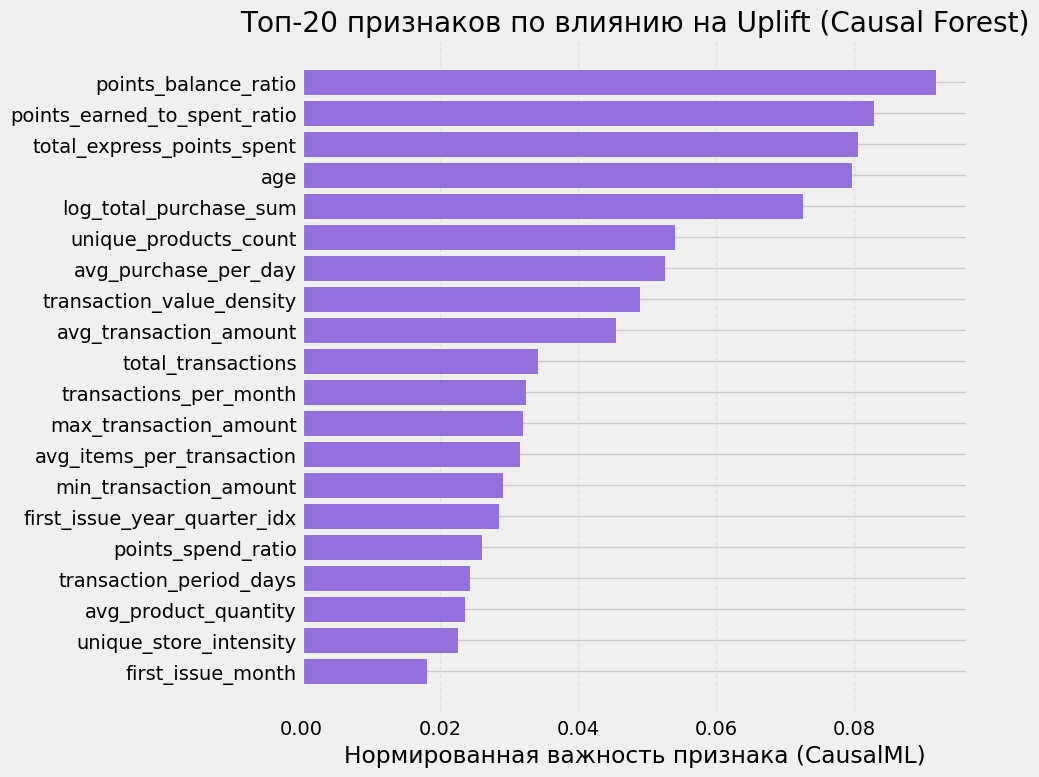

In [6]:
# feature importance

feature_importances = uplift_rf.feature_importances_

fi_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': feature_importances
}).sort_values('importance', ascending=False)

TOP_N = 20
top_imp = fi_df.head(TOP_N)

plt.figure(figsize=(10, 8))
y_pos = np.arange(len(top_imp))
plt.barh(y_pos, top_imp['importance'].values[::-1], color='mediumpurple')
plt.yticks(y_pos, top_imp['feature'].values[::-1])
plt.xlabel("Нормированная важность признака (CausalML)")
plt.title(f"Топ-{TOP_N} признаков по влиянию на Uplift (Causal Forest)")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()